In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    {'A':[14.00,90.20,90.95,96.27,91.21],
     'B':[103.02,107.26,110.35,114.23,114.68], 
     'C':['big','small','big','small','small']})

df

,A,B,C
0,14.00,103.02,big
1,90.20,107.26,small
2,90.95,110.35,big
3,96.27,114.23,small
4,91.21,114.68,small


In [2]:
(df["A"] - df["A"].min() ) / (df["A"].max() - df["A"].min())

0    0.000000
1    0.926219
2    0.935335
3    1.000000
4    0.938495
Name: A, dtype: float64

In [3]:
(df["B"] - df["B"].mean() ) / (df["B"].std())

0   -1.405250
1   -0.540230
2    0.090174
3    0.881749
4    0.973556
Name: B, dtype: float64

In [4]:
edges = pd.DataFrame({'source': [0, 1, 2], 
                    'target': [2, 2, 3],
                    'weight': [3, 4, 5],
                    'color': ['red', 'blue', 'blue']})
edges

,source,target,weight,color
0,0,2,3,red
1,1,2,4,blue
2,2,3,5,blue


In [5]:
print(edges.dtypes)
print(pd.get_dummies(edges))

source     int64
target     int64
weight     int64
color     object
dtype: object
   source  target  weight  color_blue  color_red
0       0       2       3       False       True
1       1       2       4        True      False
2       2       3       5        True      False


In [6]:
weight_dict = {3:"M", 4:"L", 5:"XL"}
edges["weight_sign"] = edges["weight"].map(weight_dict)
weight_sign = pd.get_dummies(edges["weight_sign"])
weight_sign

,L,M,XL
0,False,True,False
1,True,False,False
2,False,False,True


In [7]:
pd.concat([edges, weight_sign], axis=1)

,source,target,weight,color,weight_sign,L,M,XL
0,0,2,3,red,M,False,True,False
1,1,2,4,blue,L,True,False,False
2,2,3,5,blue,XL,False,False,True


In [8]:
raw_data = {'regiment': ['Nighthawks', 'Nighthawks', 'Nighthawks', 'Nighthawks', 
                        'Dragoons', 'Dragoons', 'Dragoons', 'Dragoons', 'Scouts', 'Scouts', 'Scouts', 'Scouts'],
            'company': ['1st', '1st', '2nd', '2nd', '1st', '1st', '2nd', '2nd','1st', '1st', '2nd', '2nd'],
            'name': ['Miller', 'Jacobson', 'Ali', 'Milner', 'Cooze', 'Jacon',
                     'Ryaner', 'Sone', 'Sloan', 'Piger', 'Riani', 'Ali'],
            'preTestScore': [4, 24, 31, 2, 3, 4, 24, 31, 2, 3, 2, 3],
            'postTestScore': [25, 94, 57, 62, 70, 25, 94, 57, 62, 70, 62, 70]}

df = pd.DataFrame(raw_data)
df

,regiment,company,name,preTestScore,postTestScore
0,Nighthawks,1st,Miller,4,25
1,Nighthawks,1st,Jacobson,24,94
2,Nighthawks,2nd,Ali,31,57
3,Nighthawks,2nd,Milner,2,62
4,Dragoons,1st,Cooze,3,70
5,Dragoons,1st,Jacon,4,25
6,Dragoons,2nd,Ryaner,24,94
7,Dragoons,2nd,Sone,31,57
8,Scouts,1st,Sloan,2,62
9,Scouts,1st,Piger,3,70


In [9]:
bins = [0, 25, 50, 75, 100] # bins 정의(0-25, 25-50, 60-75, 75-100)
group_names = ['Low', 'Okay', 'Good', 'Great']
categories = pd.cut(df['postTestScore'], bins, labels=group_names)
categories
#열추가
#df['categories']=categories

0       Low
1     Great
2      Good
3      Good
4      Good
5       Low
6     Great
7      Good
8      Good
9      Good
10     Good
11     Good
Name: postTestScore, dtype: category
Categories (4, object): ['Low' < 'Okay' < 'Good' < 'Great']

In [10]:
raw_data = {'first_name': ['Jason', np.nan, 'Tina', 'Jake', 'Amy'], 
            'last_name': ['Miller', np.nan, 'Ali', 'Milner', 'Cooze'], 
            'age': [42, np.nan, 36, 24, 73], 
            'gender': ['m', np.nan, 'f', 'm', 'f'], 
            'preTestScore': [4, np.nan, np.nan, 2, 3],
            'postTestScore': [25, np.nan, np.nan, 62, 70]}

df = pd.DataFrame(raw_data)
df

,first_name,last_name,age,gender,preTestScore,postTestScore
0,Jason,Miller,42.0,m,4.0,25.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Tina,Ali,36.0,f,NaN,NaN
3,Jake,Milner,24.0,m,2.0,62.0
4,Amy,Cooze,73.0,f,3.0,70.0


In [11]:
df.isnull()

,first_name,last_name,age,gender,preTestScore,postTestScore
0,False,False,False,False,False,False
1,True,True,True,True,True,True
2,False,False,False,False,True,True
3,False,False,False,False,False,False
4,False,False,False,False,False,False


In [12]:
df.isnull().sum() / len(df)

first_name       0.2
last_name        0.2
age              0.2
gender           0.2
preTestScore     0.4
postTestScore    0.4
dtype: float64

In [13]:
df.dropna()

,first_name,last_name,age,gender,preTestScore,postTestScore
0,Jason,Miller,42.0,m,4.0,25.0
3,Jake,Milner,24.0,m,2.0,62.0
4,Amy,Cooze,73.0,f,3.0,70.0


In [14]:
df_cleaned = df.dropna(how='all')#행 삭제
df_cleaned

,first_name,last_name,age,gender,preTestScore,postTestScore
0,Jason,Miller,42.0,m,4.0,25.0
2,Tina,Ali,36.0,f,NaN,NaN
3,Jake,Milner,24.0,m,2.0,62.0
4,Amy,Cooze,73.0,f,3.0,70.0


In [15]:
df['location'] = np.nan
df.dropna(axis=1, how='all')

,first_name,last_name,age,gender,preTestScore,postTestScore
0,Jason,Miller,42.0,m,4.0,25.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Tina,Ali,36.0,f,NaN,NaN
3,Jake,Milner,24.0,m,2.0,62.0
4,Amy,Cooze,73.0,f,3.0,70.0


In [16]:
df.dropna(thresh=1)#행 기준

,first_name,last_name,age,gender,preTestScore,postTestScore,location
0,Jason,Miller,42.0,m,4.0,25.0,NaN
2,Tina,Ali,36.0,f,NaN,NaN,NaN
3,Jake,Milner,24.0,m,2.0,62.0,NaN
4,Amy,Cooze,73.0,f,3.0,70.0,NaN


In [17]:
df.dropna(axis=1, thresh=4)

,first_name,last_name,age,gender
0,Jason,Miller,42.0,m
1,NaN,NaN,NaN,NaN
2,Tina,Ali,36.0,f
3,Jake,Milner,24.0,m
4,Amy,Cooze,73.0,f


In [18]:
df.fillna(0)

,first_name,last_name,age,gender,preTestScore,postTestScore,location
0,Jason,Miller,42.0,m,4.0,25.0,0.0
1,0,0,0.0,0,0.0,0.0,0.0
2,Tina,Ali,36.0,f,0.0,0.0,0.0
3,Jake,Milner,24.0,m,2.0,62.0,0.0
4,Amy,Cooze,73.0,f,3.0,70.0,0.0


In [19]:
df.fillna({"preTestScore": 0}, inplace=True)#권장
df["postTestScore"].fillna(df["postTestScore"].mean(), inplace=True)
df

C:\Users\DANA-LAB\AppData\Local\Temp\ipykernel_36704\683665173.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["postTestScore"].fillna(df["postTestScore"].mean(), inplace=True)


,first_name,last_name,age,gender,preTestScore,postTestScore,location
0,Jason,Miller,42.0,m,4.0,25.000000,NaN
1,NaN,NaN,NaN,NaN,0.0,52.333333,NaN
2,Tina,Ali,36.0,f,0.0,52.333333,NaN
3,Jake,Milner,24.0,m,2.0,62.000000,NaN
4,Amy,Cooze,73.0,f,3.0,70.000000,NaN


In [20]:
temp = df.groupby("gender")["postTestScore"].transform("mean")
df.fillna({"postTestScore": temp}, inplace=True)
print(temp)
print(df)

0    43.500000
1          NaN
2    61.166667
3    43.500000
4    61.166667
Name: postTestScore, dtype: float64
  first_name last_name   age gender  preTestScore  postTestScore  location
0      Jason    Miller  42.0      m           4.0      25.000000       NaN
1        NaN       NaN   NaN    NaN           0.0      52.333333       NaN
2       Tina       Ali  36.0      f           0.0      52.333333       NaN
3       Jake    Milner  24.0      m           2.0      62.000000       NaN
4        Amy     Cooze  73.0      f           3.0      70.000000       NaN


In [21]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = './data/titanic'

data_files = sorted([os.path.join(DATA_DIR, filename)
     for filename in os.listdir(DATA_DIR)], reverse=True)
data_files

['./data/titanic\\train.csv', './data/titanic\\test.csv']

In [22]:
# (1) 데이터프레임을 각 파일에서 읽어온 후 df_list에 추가
df_list = []
for filename in data_files:
    df_list.append(pd.read_csv(filename)) 

# (2) 두 개의 데이터프레임을 하나로 통합
df = pd.concat(df_list) 

# (3) 인덱스 초기화 
df = df.reset_index(drop=True) 

# (4) 결과 출력
df.head(5)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
df.head(2).T

,0,1
PassengerId,1,2
Survived,0.0,1.0
Pclass,3,1
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th..."
Gender,male,female
Age,22.0,38.0
SibSp,1,1
Parch,0,0
Ticket,A/5 21171,PC 17599
Fare,7.25,71.2833


In [24]:
# (1) 데이터를 소수점 두 번째 자리까지 출력
pd.options.display.float_format = '{:.2f}'.format
 
# (2) 결측치 값의 합을 데이터의 개수로 나눠 비율로 출력
df.isnull().sum() / len(df) * 100

PassengerId    0.00
Survived      31.93
Pclass         0.00
Name           0.00
Gender         0.00
Age           20.09
SibSp          0.00
Parch          0.00
Ticket         0.00
Fare           0.08
Cabin         77.46
Embarked       0.15
dtype: float64

In [25]:
df.drop('Cabin', axis=1, inplace=True)
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [26]:
df.dropna(subset=["Survived"], inplace=True)
df.tail()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
886,887,0.00,2,"Montvila, Rev. Juozas",male,27.00,0,0,211536,13.00,S
887,888,1.00,1,"Graham, Miss. Margaret Edith",female,19.00,0,0,112053,30.00,S
888,889,0.00,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,S
889,890,1.00,1,"Behr, Mr. Karl Howell",male,26.00,0,0,111369,30.00,C
890,891,0.00,3,"Dooley, Mr. Patrick",male,32.00,0,0,370376,7.75,Q


In [27]:
df[df["Age"].notnull()].groupby(["Gender"])["Age"].mean()

Gender
female   27.92
male     30.73
Name: Age, dtype: float64

In [28]:
df[df["Age"].notnull()].groupby(["Pclass"])["Age"].mean()

Pclass
1   38.23
2   29.88
3   25.14
Name: Age, dtype: float64

In [29]:
df.fillna({"Age":df.groupby("Pclass")["Age"].transform("mean")}, inplace=True)
df.isnull().sum() / len(df) * 100

PassengerId   0.00
Survived      0.00
Pclass        0.00
Name          0.00
Gender        0.00
Age           0.00
SibSp         0.00
Parch         0.00
Ticket        0.00
Fare          0.00
Embarked      0.22
dtype: float64

In [30]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1.00,1,"Icard, Miss. Amelie",female,38.00,0,0,113572,80.00,NaN
829,830,1.00,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.00,0,0,113572,80.00,NaN


In [31]:
count = df.groupby("Embarked")["Embarked"].count()
count

Embarked
C    168
Q     77
S    644
Name: Embarked, dtype: int64

In [32]:
df.iloc[[61,829],10] = "S"
df.iloc[[61,829],10]

61     S
829    S
Name: Embarked, dtype: object

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    float64
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(3), int64(4), object(4)
memory usage: 83.5+ KB


In [34]:
ctg_columns = ["Pclass", "Gender", "Embarked"]

for c in ctg_columns:
    onehot = pd.get_dummies(df[c], prefix=c)#해당 열 원핫인코딩
    
    #index로 병합하여 다시 df에 저장 df = pd.concat([df, onehot], axis=1)
    df = pd.merge(df,onehot, how="inner", left_index=True, right_index=True)

df.head(2).T

,0,1
PassengerId,1,2
Survived,0.00,1.00
Pclass,3,1
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th..."
Gender,male,female
Age,22.00,38.00
SibSp,1,1
Parch,0,0
Ticket,A/5 21171,PC 17599
Fare,7.25,71.28


In [35]:
ctg_columns = ["Pclass", "Gender", "Embarked"]

for c in ctg_columns:
    onehot = pd.get_dummies(df[c], prefix=c)#해당 열 원핫인코딩
    
    #index로 병합하여 다시 df에 저장 df = pd.concat([df, onehot], axis=1)
    df = pd.merge(df,onehot, how="inner", left_index=True, right_index=True)

df.head(2).T

,0,1
PassengerId,1,2
Survived,0.00,1.00
Pclass,3,1
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th..."
Gender,male,female
Age,22.00,38.00
SibSp,1,1
Parch,0,0
Ticket,A/5 21171,PC 17599
Fare,7.25,71.28


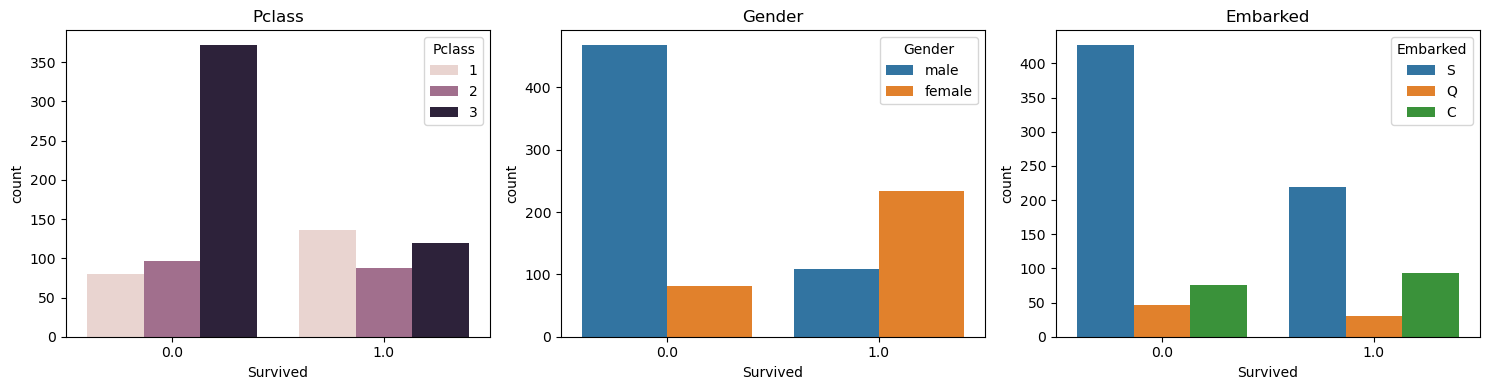

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

#ctg_columns = ["Pclass", "Gender", "Embarked"]

#크기 지정
plt.figure(figsize=(15,4))

for i in range(len(ctg_columns)):
    plt.subplot(1,3,i+1)#위치

    #그래프 그리기
    sns.countplot(x="Survived", hue=ctg_columns[i], data=df)

    #그래프 제목
    plt.title(ctg_columns[i])

plt.tight_layout()
plt.show()